In [26]:
import pandas as pd

from Modules.text_processor import TextProcessor

# readind the dataset
file_path = 'https://raw.githubusercontent.com/rfordatascience/tidytuesday/main/data/2025/2025-02-25/article_dat.csv'
df = pd.read_csv(file_path)

# instantiating the text processor
text_processor = TextProcessor(download=True)

[nltk_data] Downloading package stopwords to /home/onyxia/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package punkt to /home/onyxia/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to /home/onyxia/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


In [27]:
import sys

print(sys.executable)

/home/onyxia/work/Projet-python-2A/.venv/bin/python


In [28]:
df.columns

Index(['pmid', 'doi', 'jabbrv', 'journal', 'year', 'month', 'day', 'title',
       'abstract', 'keywords', 'study_aim', 'study_location',
       'study_year_start', 'study_year_end', 'study_type', 'data_source',
       'race1', 'race1_ss', 'race2', 'race2_ss', 'race3', 'race3_ss', 'race4',
       'race4_ss', 'race5', 'race5_ss', 'race6', 'race6_ss', 'race7',
       'race7_ss', 'race8', 'race8_ss', 'eth1', 'eth1_ss', 'eth2', 'eth2_ss',
       'eth3', 'eth3_ss', 'eth4', 'eth4_ss', 'eth5', 'eth5_ss', 'eth6',
       'eth6_ss', 'eth7', 'eth7_ss', 'eth8', 'eth8_ss', 'access_to_care',
       'treatment_received', 'health_outcome', 'cancer_ovarian',
       'cancer_uterine', 'cancer_cervical', 'cancer_vulvar', 'other_gyn_onc',
       'endo', 'fibroids', 'other_gyn_surg', 'fert', 'matmorbmort',
       'other_preg', 'phys_div', 'other', 'covid'],
      dtype='str')

## Traitements initiaux

In [ ]:
# Selection des colonnes de type chaine de caractères d'intérêt
target_col = ['study_type', 'data_source', 'abstract', 'study_aim', 'study_location', 'title']
target_col

['study_type',
 'data_source',
 'abstract',
 'study_aim',
 'study_location',
 'title']

In [35]:
# Selection de la table d'intérêt
df.loc[:, target_col].sample(4, random_state=4)

,study_type,data_source,abstract,study_aim,study_location,title
99,Retrospective cohort,National Cancer Database,Delays in time to treatment initiation (TTI) w...,to investigate the disparities in delays in ti...,USA,Delays in definitive cervical cancer treatment...
248,Retrospective Cohort,American College of Surgeons' National Surgica...,Black race has been associated with increased ...,Black race has been associated with increased ...,USA,Laparoscopy decreases the disparity in postope...
92,Retrospective cohort,"walter reed army medical center, wilford hall ...",To evaluate assisted reproduction technology (...,To evaluate ART utilization and outcomes in mi...,NaN,Will decreasing assisted reproduction technolo...
61,Retrospective cohort,"Surveillance, Epidemiology, and End Results; M...",To examine whether treatment with guideline-re...,To examine whether treatment with guideline-re...,USA,Racial disparities in the treatment of advance...


In [36]:
# Afficher le type d'étude que compte la base de données
print(df["study_type"].unique().tolist())
print(len(df["study_type"].unique().tolist()))

df.groupby("study_type").size()

['Retrospective cohort', 'Cross-sectional', 'Case-control', 'Prospective cohort', 'RCT', 'Registry', 'Retrospective Cohort', 'Prospective Cohort', 'Cross-Sectional', nan]
10


study_type
Case-control              9
Cross-Sectional          20
Cross-sectional          21
Prospective Cohort        6
Prospective cohort       16
RCT                       8
Registry                 23
Retrospective Cohort     82
Retrospective cohort    130
dtype: int64

Ainsi, on constate que nous avons la répétition de certaines modalité à une petite différence près. Ainsi, il faut pouvoir faire en sorte de regrouper ces modalités, ou faire un pré traitement en vu de les uniformiser.

**Néttoyage très poussé car nous allons utiliser le TD-IDF**
- Mettre tous les textes en minuscule
- Retirer toutes la pontuation (, !, ?, etc)
- Remplacer les espaces multiples par des espaces simple
- Retirer les mot très fréquents sans valeur : of, the, and, etc
- Supprimer les espaces en fin et debut de texte

In [49]:
# Application d'un premier traitement aux colonnes d'intérêt
for col in target_col:
    df["processed_"+col] = df[col].apply(
        lambda x: None if " ".join(text_processor.preprocess(x)) == "" else " ".join(text_processor.preprocess(x)) # Reconstitution des phrases apres avoir réalisé le prétraitement sur les chaines de caractères
        # On s'assure de bien concerver NA lorsque l'information n'est pas disponible
    )

df.loc[:, ["processed_"+col for col in target_col]].sample(4, random_state=4)

,processed_study_type,processed_data_source,processed_abstract,processed_study_aim,processed_study_location,processed_title
99,retrospective cohort,national cancer database,delays time treatment initiation tti definitiv...,investigate disparities delays time treatment ...,usa,delays definitive cervical cancer treatment an...
248,retrospective cohort,american college surgeons national surgical qu...,black race associated increased day morbidity ...,black race associated increased day morbidity ...,usa,laparoscopy decreases disparity postoperative ...
92,retrospective cohort,walter reed army medical center wilford hall m...,evaluate assisted reproduction technology art ...,evaluate art utilization outcomes minority wom...,NaN,decreasing assisted reproduction technology co...
61,retrospective cohort,surveillance epidemiology end results medicare...,examine whether treatment guideline recommende...,examine whether treatment guideline recommende...,usa,racial disparities treatment advanced epitheli...


In [51]:
# Afficher le type d'étude que compte la base de données
print(df["processed_study_type"].unique().tolist())
print(len(df["processed_study_type"].unique().tolist()))

df.groupby("processed_study_type").size()

['retrospective cohort', 'cross sectional', 'case control', 'prospective cohort', 'rct', 'registry', nan]
7


processed_study_type
case control              9
cross sectional          41
prospective cohort       22
rct                       8
registry                 23
retrospective cohort    212
dtype: int64

In [52]:
# Mettons la 1ere lettre de chaque moi en majuscule    if x == "rct" else x.upper()
df["processed_study_type"] = df["processed_study_type"].apply(
    lambda x: x.upper() if isinstance(x, str) and x == "rct"
    else x.title() if isinstance(x, str)
    else x
    )
df.groupby("processed_study_type").size()

processed_study_type
Case Control              9
Cross Sectional          41
Prospective Cohort       22
RCT                       8
Registry                 23
Retrospective Cohort    212
dtype: int64

In [53]:
# Vérifions si on a des lignes ou on a des ""
for col in target_col:
    nb = df.loc[df[col] == ""].shape[0]
    if nb != 0:
        print(col)

# Aucune des colonnes d'intérêt ne possède des cellules avec "" pour indiquer une données manquante

In [11]:
# Le nombre de données manquantes par colonnes d'intérêt
res = []
for col in target_col:
    nb = sum(df["processed_"+col].isna())
    res.append((col, nb))

res

[('study_year_end', 318),
 ('study_type', 3),
 ('study_year_start', 318),
 ('data_source', 4),
 ('abstract', 6),
 ('study_aim', 3),
 ('study_location', 12),
 ('title', 0)]

- On constate que les colonnes renseignant les dates de début et de fin ne contiennent aucune donnée
- Parmis tous les articles, 3 d'entre eux n'ont pas de type
- On observe que les autres colonnes contiennent également des données manquantes

In [12]:
# Visualisation des lignes n'ayant de type
df.loc[df["processed_study_type"].isna(), ["processed_"+col for col in target_col]]

,processed_study_year_end,processed_study_type,processed_study_year_start,processed_data_source,processed_abstract,processed_study_aim,processed_study_location,processed_title
315,None,NaN,None,NaN,assess association allostatic load estimate ch...,NaN,NaN,allostatic load adverse pregnancy outcomes
316,None,NaN,None,NaN,investigate factors associated differential st...,NaN,NaN,health care disparity state specific pregnancy...
317,None,NaN,None,NaN,examine postoperative day morbidity mortality ...,NaN,NaN,racial disparity day morbidity mortality surge...


On observe que les trois lignes ne possédant pas de type d'étude, sont celles qui comportent le plus de données manquantes sur les colonnes d'intérêt. 
Etant données que la colonne `abstract` n'est pas vide, ces lignes restent importantes car nous réaliserons un clustering des études à partir de cette variable.

## Analyse des `Abstracts`

In [54]:
#abstracts = df['abstract'].apply(
#    lambda x: text_processor.preprocess(x)
#)
#df['processed_abstract'] = abstracts

abstracts = df['processed_abstract'].dropna()

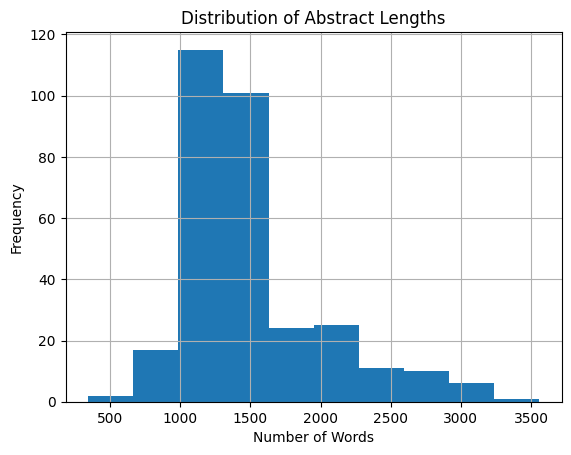

In [55]:
import matplotlib.pyplot as plt

plt.hist([len(abstract) for abstract in abstracts])
plt.xlabel("Number of Words")
plt.ylabel("Frequency")
plt.title("Distribution of Abstract Lengths")
plt.grid(True)
plt.show()

Il faut donc qu'on enlève les abstracts de moins de 50 mots. car il n'y en a pas de moins de 50.

In [22]:
# removing abstracts with less than 50 words because we have some abstracts with very few words like 0 and we want to focus on more substantial abstracts for our analysis
# df = df[df['processed_abstracts'].str.split().apply(len) > 50]

## Frequences des mots dans le corpus

In [56]:
#df['processed_abstracts'].head()
df['processed_abstract'].head()

0    evaluate whether women medicaid less likely pr...
1    compare postoperative outcomes primary payer s...
2    germline mutations occur approximately patient...
3    evaluate patients advanced ovarian cancer oc u...
4    although black patients endometrial cancer ec ...
Name: processed_abstract, dtype: str

In [58]:
# all_absracts_cleaned = df['processed_abstracts'].apply(lambda x: " ".join(x))

all_absracts_cleaned = df['processed_abstract'].dropna()
all_absracts_cleaned = " ".join(all_absracts_cleaned)
dict_of_words_occurences = text_processor.count_word_frequencies(text=all_absracts_cleaned, top_n=10000, preprocess=False)
len(dict_of_words_occurences)

# 4664

4664

In [59]:
dict_of_words_occurences

{'women': 1538,
 'black': 828,
 'white': 700,
 'patients': 679,
 'cancer': 646,
 'hispanic': 605,
 'ci': 589,
 'race': 485,
 'among': 469,
 'risk': 458,
 'non': 448,
 'compared': 443,
 'racial': 375,
 'care': 370,
 'lt': 370,
 'adjusted': 334,
 'study': 326,
 'survival': 326,
 'treatment': 321,
 'maternal': 307,
 'associated': 301,
 'pregnancy': 300,
 'vs': 290,
 'ratio': 288,
 'confidence': 286,
 'odds': 285,
 'disparities': 278,
 'interval': 262,
 'higher': 259,
 'age': 255,
 'rates': 245,
 'likely': 243,
 'differences': 233,
 'ethnicity': 223,
 'data': 212,
 'birth': 210,
 'mortality': 209,
 'analysis': 208,
 'endometrial': 205,
 'stage': 204,
 'using': 195,
 'outcomes': 193,
 'morbidity': 193,
 'used': 192,
 'severe': 190,
 'factors': 189,
 'delivery': 188,
 'ethnic': 181,
 'years': 179,
 'american': 174,
 'ovarian': 173,
 'regression': 170,
 'less': 169,
 'overall': 167,
 'increased': 164,
 'health': 162,
 'significantly': 159,
 'identified': 158,
 'african': 157,
 'disease': 156,

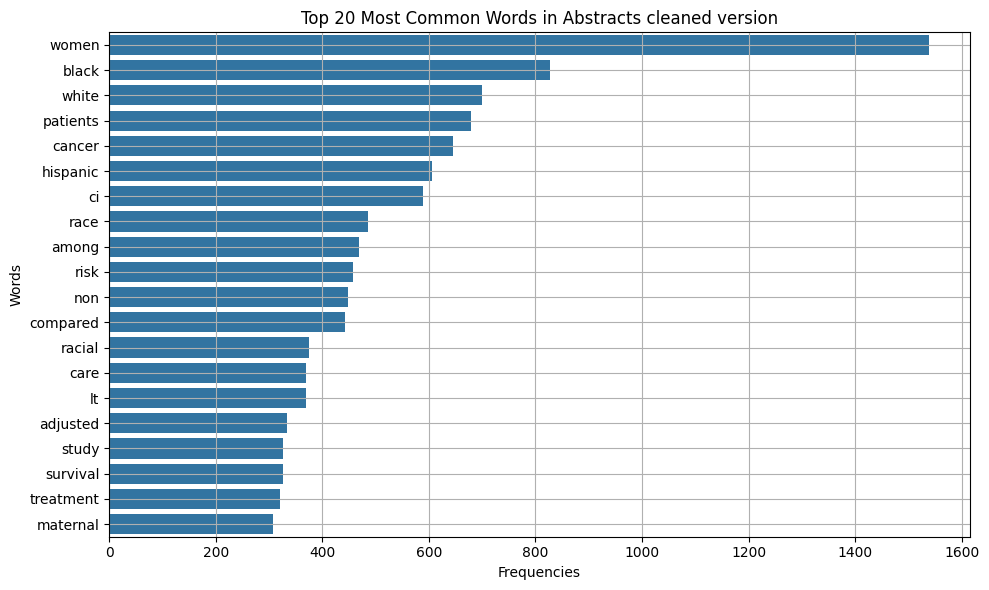

In [60]:
from Modules.graphic_drawer import GraphicDrawer

graphic_drawer = GraphicDrawer()
graphic_drawer.draw_bar_plot(dict_of_words_occurences, top_n=20, title="Top 20 Most Common Words in Abstracts cleaned version", ylabel="Words", xlabel="Frequencies")

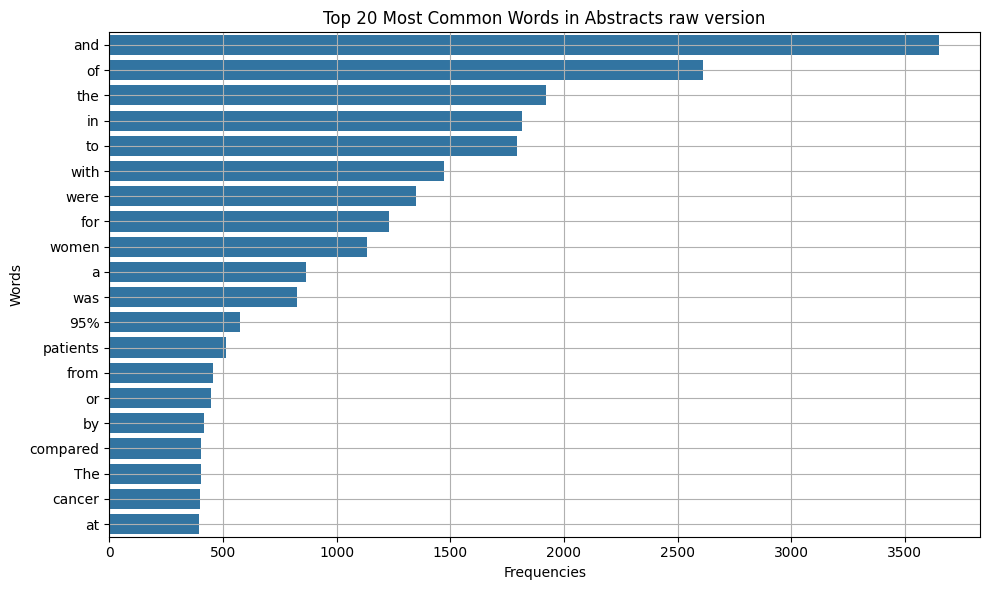

In [61]:
all_absracts_raw = " ".join(df['abstract'].apply(lambda x: str(x)))
dict_of_words_occurences_raw_version = text_processor.count_word_frequencies(all_absracts_raw, top_n=1000000000, preprocess=False)
graphic_drawer.draw_bar_plot(dict_of_words_occurences_raw_version, top_n=20, title="Top 20 Most Common Words in Abstracts raw version", ylabel="Words", xlabel="Frequencies")

In [62]:
len(dict_of_words_occurences_raw_version)

13417

On voit qu'avant le traitement du texte, les mots inutile telsque `and, of, the, to, with, were, for, a, the` etc. sont présent dans le corpus avant traitement. Alors qu'après traitement ceux-ci disparaissent (`13417 vs 4664`).

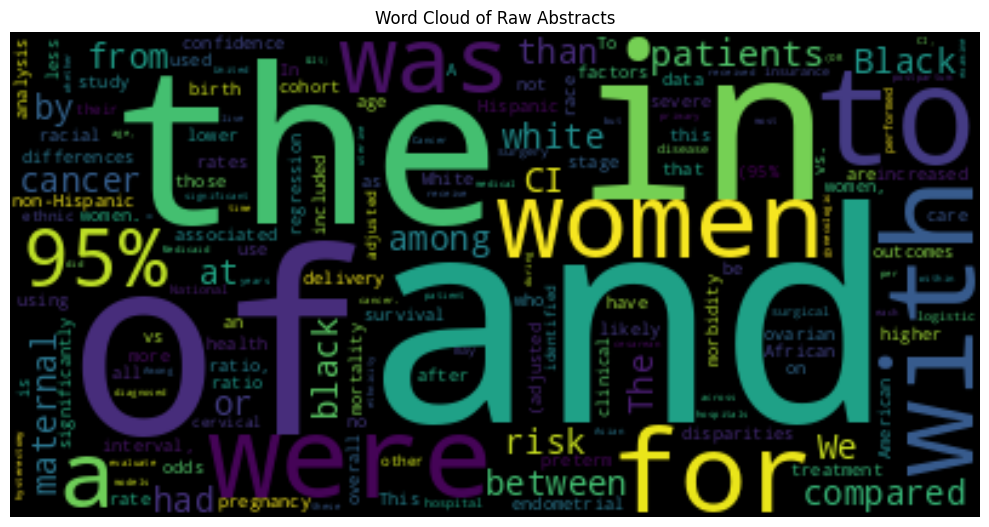

In [65]:
graphic_drawer.draw_wordcloud_from_freq(dict_of_words_occurences_raw_version, title="Word Cloud of Raw Abstracts")

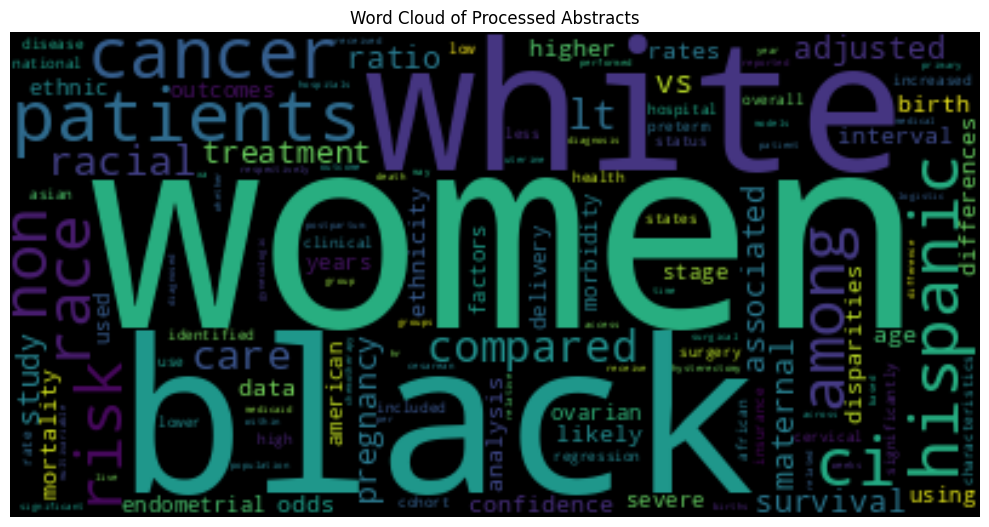

In [66]:
graphic_drawer.draw_wordcloud_from_freq(dict_of_words_occurences, title="Word Cloud of Processed Abstracts")

On voit qu'avant le traitement du texte, les mots inutile telsque `and, of, the, to, with, were, for, a, the` etc. sont présent dans le corpus avant traitement. Alors qu'après traitement ceux-ci disparaissent (`13417 vs 4664`).

Avec `tf-idf`, on aura des vecteurs de `4664` dimensions par abstract, ce qui est enorme et problématique. En effet pour clusteriser/classifier nos articles sur la base des abstracts, il faut les vectoriser et calculer des métriques de similarités (distance, cosinus similarité etc...) entre eux. Or les distances , normes deviennent moins informatives dans un espace de grande dimension. Pour cela, nous utiliserons le `SciBert` qui permet de palier à ce problème et même fait plus : il tient compte de l'aspect sémantique des abstract au lieu de se baser sur le nombre d'occurences qui certes encode l'aspect semantique comme vue avec la `fréquence des mots` vue en amont (**On arrive à voir quand même de quoi le corpus parle en générale**) mais moins précis.

Par conséquent pour utiliser `SciBert`, il faut respecter au mieux la structure sémantique. Donc supprimer `les stopwords`, `tokenizer`, supprimer certains `regex` comme les `chiffres`, la `ponctuation` peuvent fortemen casser le sens des abstracts. Les autres traitements restent valables (du coup on va redinir notre classe) pour tenir compte d'un `preprocessing` adapté à la vectorisation `SciBert`.

# Vectorisation des abstracts avec SciBERT

## Formalisme et cas d’usage du transformer

---

## 1. Entrée du modèle (tokenization)

Soit un texte :

"deep learning for image classification"

Après tokenization avec SciBERT :

inputs["input_ids"] =
[101, 2784, 4083, 2005, 3746, 5579, 102]

inputs["attention_mask"] =
[1, 1, 1, 1, 1, 1, 1]

### Interprétation :

- 101 = token [CLS] (début de phrase)
- 102 = token [SEP] (fin de phrase)
- les autres = tokens du texte

---

## 1.1 Qu’est-ce que [PAD] ?

Le token [PAD] signifie padding (remplissage).

Il est utilisé lorsque plusieurs textes sont traités ensemble (batch), car ils n’ont pas la même longueur.

### Exemple :

"deep learning"  
"climate change impacts marine ecosystems"

Devient :

["deep", "learning", [PAD], [PAD], [PAD]]  
["climate", "change", "impacts", "marine", "ecosystems"]

### Rôle de [PAD] :

- rendre toutes les séquences de même longueur
- permettre le traitement en batch
- ne pas ajouter d’information sémantique

---

## 1.2 Attention mask

Pour éviter que [PAD] influence le modèle, on utilise un attention mask :

attention_mask:
[1, 1, 0, 0, 0]

- 1 = vrai token (important)
- 0 = padding (ignoré)

---

## 2. Sortie du modèle BERT

On applique :

outputs = model(**inputs)

Le modèle retourne :

outputs.last_hidden_state  
shape = (batch_size, sequence_length, hidden_size)

### Exemple concret :

shape = (1, 7, 768)

### Interprétation :

Chaque token devient un vecteur de dimension 768 :

token 1 ([CLS])      → vector (768)  
token 2 ("deep")     → vector (768)  
token 3 ("learning") → vector (768)  
...  
token 7 ([SEP])      → vector (768)

---

## 3. Pourquoi on ne peut pas utiliser directement BERT

On veut UN vecteur par phrase :

$$
(1, 768)
$$

Mais BERT donne :

$$
(1, 7, 768)
$$

Donc il faut une opération de réduction : pooling.

---

## 4. Mean pooling (idée mathématique)

Soit :

$$
H = [h_1, h_2, ..., h_n]
$$

où chaque $h_i \in \mathbb{R}^{768}$

Mean pooling :

$$
h_{\text{sentence}} = \frac{1}{n} \sum_{i=1}^{n} h_i
$$

---

## 4.1 Mean pooling avec attention mask

Sans attention mask, les tokens [PAD] influencent la moyenne.

Avec mask :

$$
h = \frac{\sum_{i=1}^{n} m_i h_i}{\sum_{i=1}^{n} m_i}
$$

où :

- $m_i = 1$ si token valide  
- $m_i = 0$ si [PAD]

---

## 5. Code correspondant

```python
token_embeddings = outputs.last_hidden_state

mask = attention_mask.unsqueeze(-1)
mask = mask.expand(token_embeddings.size())

masked_embeddings = token_embeddings * mask

summed = masked_embeddings.sum(dim=1)
counts = mask.sum(dim=1)

sentence_embedding = summed / counts

In [67]:
text_processor_with_scibert = TextProcessor(use_scibert=True, download=False)
abstracts_scibert = df['abstract'].apply(
    lambda x: text_processor_with_scibert.preprocess(x)
)

config.json:   0%|          | 0.00/385 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

pytorch_model.bin:   0%|          | 0.00/442M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: allenai/scibert_scivocab_uncased
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.predictions.decoder.weight             | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.predictions.decoder.bias               | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


model.safetensors:   0%|          | 0.00/442M [00:00<?, ?B/s]

!!!!!!!!!!!!!!!!!!!!!

In [ ]:
sum(df['abstract'] == "")
sum(df['abstract'].apply(lambda x: isinstance(x, str))) 

sum(abstracts_scibert == "") # d'ou viennent les 6

312

In [72]:
df['abstracts_scibert'] = abstracts_scibert
# df['abstracts_scibert'] = df['abstracts_scibert'].apply(lambda x: " ".join(x))
all_absracts_scibert = " ".join(df['abstracts_scibert'].apply(lambda x: str(x)))
dict_of_words_occurences_scibert_version = text_processor_with_scibert.count_word_frequencies(all_absracts_scibert, top_n=1000000000, preprocess=False)
len(dict_of_words_occurences_scibert_version)

13414

In [73]:
dict_of_words_occurences_scibert_version

{'and': 3648,
 'of': 2614,
 'the': 1921,
 'in': 1815,
 'to': 1793,
 'with': 1473,
 'were': 1348,
 'for': 1231,
 'women': 1135,
 'a': 865,
 'was': 826,
 '95%': 575,
 'patients': 513,
 'from': 457,
 'or': 446,
 'by': 415,
 'compared': 403,
 'The': 402,
 'cancer': 401,
 'at': 395,
 'among': 374,
 'CI': 358,
 'Black': 353,
 'between': 340,
 'risk': 332,
 'white': 320,
 'black': 310,
 'than': 305,
 'had': 294,
 'maternal': 293,
 'We': 290,
 'non-Hispanic': 288,
 'associated': 287,
 'as': 284,
 'confidence': 283,
 'racial': 273,
 'care': 272,
 'study': 268,
 'race': 266,
 'survival': 256,
 'more': 254,
 'that': 249,
 'higher': 247,
 'treatment': 244,
 'likely': 243,
 'disparities': 237,
 'are': 236,
 'is': 233,
 'odds': 232,
 'not': 230,
 'White': 229,
 'on': 229,
 'who': 226,
 'interval,': 212,
 'an': 207,
 'differences': 205,
 'rates': 205,
 'endometrial': 191,
 'Hispanic': 189,
 'used': 185,
 '(adjusted': 182,
 'severe': 180,
 'women.': 178,
 'mortality': 176,
 'have': 173,
 'pregnancy': 

On passe de `4664` à `13414` le nombre de mots uniques du corpus a donc beaucoup augmenté en se rapprochant du nombre de mots du texte non traité qui est de `13417`.

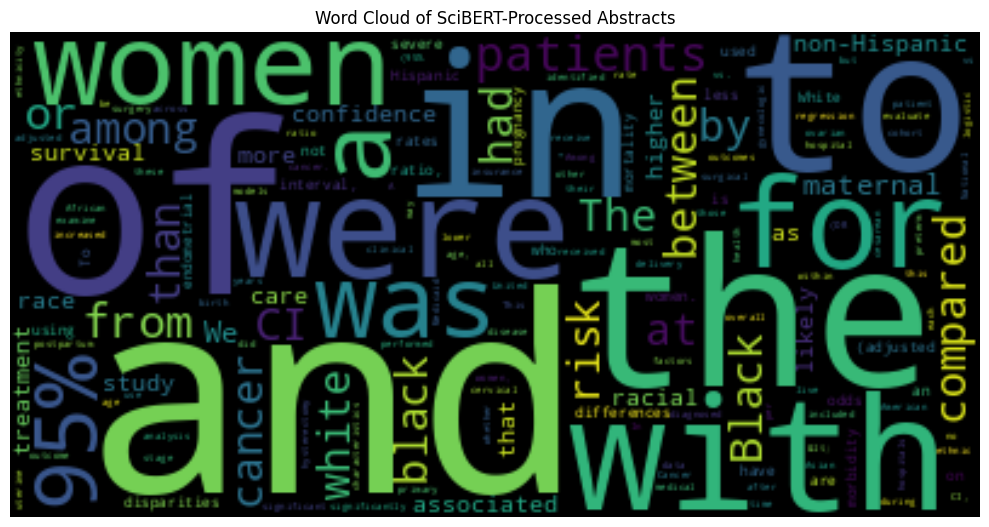

In [74]:
graphic_drawer.draw_wordcloud_from_freq(dict_of_words_occurences_scibert_version, title="Word Cloud of SciBERT-Processed Abstracts")

Là on peut voir la présense des chiffres notament `95%` pour des IC ou des tests statistiques et des `stopwords` `(to, or, etc.)`, ce qui permet de garder le contexte des données. Les trois mots manquant peuvent venir du fait qu'on ai supprimé les adresses `eamils`, les `urls`, les `tags html` et les espaces supplémentaires. Maintenant nous pouvons passer à la vectorisation.

## INTERPRETATION OF WORDCLOUDS

We can already identify several key terms. The interpretation is done iteratively from top to bottom:

- `women` is the most frequent term (1135 occurrences after removing stopwords), together with `pregnancy` $\Rightarrow$ GENRE

- `race`, `racial`, `black`, `white` $\Rightarrow$ RACE

- `non-hispanic` $\Rightarrow$ ETHNICITY

- `treatment`, `patients`, `risk`, `survival`, `care`, `cancer` $\Rightarrow$ strong dominance of health-related studies

- `disparities`, `associated`, `less`, `between`, `after` $\Rightarrow$ comparative study framework

- `95%`, `CI`, `likely`, `odds`, `interval`, `factors` $\Rightarrow$ statistical modeling / inference

---

A first overview of the dataset suggests that, even without prior knowledge of the data, the corpus consists of English scientific medical articles. These articles mainly focus on clinical studies involving race, ethnicity, and gender variables, with a strong emphasis on statistical modeling and inference methods.

## VECTORISATION DU TEXTE

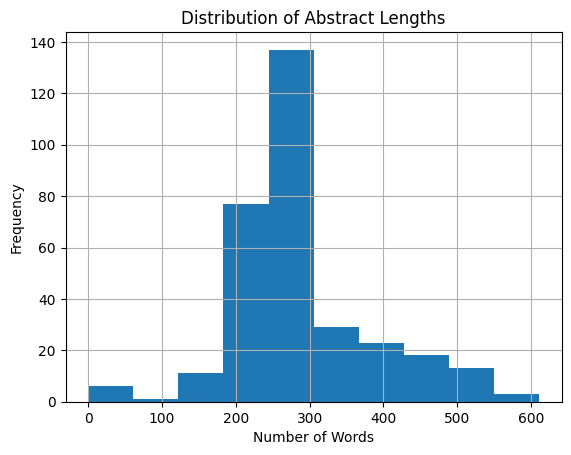

In [75]:
import matplotlib.pyplot as plt

plt.hist([len(abstract) for abstract in abstracts_scibert.apply(lambda x: str(x).split())])
plt.xlabel("Number of Words")
plt.ylabel("Frequency")
plt.title("Distribution of Abstract Lengths")
plt.grid(True)
plt.show()

In [76]:
# suppression des abstracts avec moins de 50 mots après le traitement avec SciBERT pour se concentrer sur les abstracts plus substantiels
df = df[df['abstracts_scibert'].str.split().apply(len) > 0]

La version gratuite de `SciBert` nous donne accès à des tokens de longueur `512` pour chaque élément de notre corpus. Ce qui correspond à environ `250 mots`. Or la distribution ici montre qu'on des abstract allant jusqu'à `600` mots avec le mode qui est autour de `300`. Il faut donc faire du `chunking` pour utiliser plusieurs fois les `512` tokens sur un élement du corpus c'est à dire un abstract si son nombre de mots excède les 250 (nécessite plus de 512 tokens).

In [77]:
texts = df['abstracts_scibert'].tolist()
print(f'We are now working on {len(texts)} abstracts after removing those that do not contain any words')

We are now working on 312 abstracts after removing those that do not contain any words


In [78]:
embeddings = text_processor_with_scibert.embed_scibert(texts=texts, batch_size=16) # 16 because i do not know if the user will execute this code using a GPU

Output()

In [79]:
# pre-commit install
embeddings.shape

(312, 768)

In [80]:
df.columns

Index(['pmid', 'doi', 'jabbrv', 'journal', 'year', 'month', 'day', 'title',
       'abstract', 'keywords', 'study_aim', 'study_location',
       'study_year_start', 'study_year_end', 'study_type', 'data_source',
       'race1', 'race1_ss', 'race2', 'race2_ss', 'race3', 'race3_ss', 'race4',
       'race4_ss', 'race5', 'race5_ss', 'race6', 'race6_ss', 'race7',
       'race7_ss', 'race8', 'race8_ss', 'eth1', 'eth1_ss', 'eth2', 'eth2_ss',
       'eth3', 'eth3_ss', 'eth4', 'eth4_ss', 'eth5', 'eth5_ss', 'eth6',
       'eth6_ss', 'eth7', 'eth7_ss', 'eth8', 'eth8_ss', 'access_to_care',
       'treatment_received', 'health_outcome', 'cancer_ovarian',
       'cancer_uterine', 'cancer_cervical', 'cancer_vulvar', 'other_gyn_onc',
       'endo', 'fibroids', 'other_gyn_surg', 'fert', 'matmorbmort',
       'other_preg', 'phys_div', 'other', 'covid', 'processed_study_year_end',
       'processed_study_type', 'processed_study_year_start',
       'processed_data_source', 'processed_abstract', 'processed

In [81]:
len(embeddings.tolist())

312

In [99]:
df[['study_type']]

,study_type
0,Retrospective cohort
1,Retrospective cohort
2,Retrospective cohort
3,Retrospective cohort
4,Retrospective cohort
...,...
313,Retrospective Cohort
314,Retrospective Cohort
315,NaN
316,NaN


In [82]:
df_4_umap = df[['study_type']].copy()

# convert the embeddings column into a DataFrame
emb_df = pd.DataFrame(embeddings.tolist(), index=df.index)

# concatenate
df_4_umap = pd.concat([df_4_umap, emb_df], axis=1)

# Optional: set `study_type` as the index
df_4_umap.set_index('study_type', inplace=True)

# Removing N/A entries from the study type
df_4_umap = df_4_umap[~df_4_umap.index.isna()]
print(len(df_4_umap))

309


In [97]:
df_4_umap.index

Index(['Retrospective cohort', 'Retrospective cohort', 'Retrospective cohort',
       'Retrospective cohort', 'Retrospective cohort', 'Retrospective cohort',
       'Retrospective cohort', 'Retrospective cohort', 'Retrospective cohort',
       'Cross-sectional',
       ...
       'Retrospective Cohort', 'RCT', 'Retrospective Cohort',
       'Retrospective Cohort', 'Retrospective Cohort', 'Registry',
       'Retrospective Cohort', 'Retrospective Cohort', 'Retrospective Cohort',
       'Retrospective Cohort'],
      dtype='str', name='study_type', length=309)

In [83]:
df_4_umap.values

array([[ 0.22541565, -0.23449762, -0.28892589, ..., -0.30855098,
         0.0757551 , -0.65948415],
       [ 0.1875979 , -0.32375339, -0.34593847, ..., -0.1597053 ,
        -0.00787103, -0.54400963],
       [ 0.14375083, -0.16622923, -0.45391217, ..., -0.20220304,
         0.00763974, -0.90059865],
       ...,
       [ 0.07054155, -0.46103203, -0.23587841, ...,  0.14176998,
        -0.22078209, -0.78249109],
       [ 0.06217977, -0.44012302, -0.38986376, ...,  0.00748828,
         0.11857866, -0.7956816 ],
       [ 0.37702411, -0.01407038,  0.24814522, ..., -0.36130562,
         0.05293886, -0.51245922]], shape=(309, 768))

In [84]:
df_4_umap

,0,1,2,3,4,5,6,7,8,9,...,758,759,760,761,762,763,764,765,766,767
study_type,,,,,,,,,,,,,,,,,,,,,
Retrospective cohort,0.225416,-0.234498,-0.288926,0.030493,-0.492477,-0.471557,-0.139296,1.042676,-0.350018,0.036012,...,-0.013268,0.209874,0.054995,0.232749,-0.087875,0.081621,-0.106929,-0.308551,0.075755,-0.659484
Retrospective cohort,0.187598,-0.323753,-0.345938,0.361154,-0.354200,-0.223751,0.045859,1.014536,-0.301173,0.129132,...,-0.082338,0.059743,0.067148,0.079351,-0.148120,0.079459,-0.183369,-0.159705,-0.007871,-0.544010
Retrospective cohort,0.143751,-0.166229,-0.453912,0.346619,-0.152802,-0.266087,0.054783,0.936379,-0.298088,-0.068115,...,-0.250860,0.281263,0.203590,0.022133,0.006640,-0.028318,-0.191617,-0.202203,0.007640,-0.900599
Retrospective cohort,0.108394,-0.206239,-0.431156,0.412001,-0.366370,-0.104784,0.070026,1.099878,-0.310188,0.007000,...,0.050689,0.174083,0.232694,-0.005055,-0.330744,0.117597,-0.194541,-0.091756,-0.018648,-0.566623
Retrospective cohort,-0.005680,-0.423108,-0.353241,0.434751,-0.338483,-0.082386,0.129452,0.797123,-0.360701,0.067649,...,0.061349,0.355794,0.181282,0.079322,-0.226779,-0.272281,-0.217796,0.040205,0.026566,-0.732778
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
Registry,0.165019,-0.316209,-0.172691,0.218721,-0.393803,-0.238598,0.134469,0.852967,-0.389964,0.055514,...,-0.111598,-0.024139,-0.054626,0.050511,-0.070713,-0.197474,-0.236142,-0.104272,-0.358400,-0.765062
Retrospective Cohort,0.181788,-0.508576,-0.112691,0.422862,-0.301121,-0.315530,0.201538,0.728898,-0.373630,-0.192745,...,-0.021779,0.221496,0.193409,0.116243,0.052366,-0.104712,-0.055115,-0.081926,-0.092228,-0.909588
Retrospective Cohort,0.070542,-0.461032,-0.235878,0.217765,-0.484686,-0.090104,0.314646,1.062415,-0.335390,0.055997,...,-0.034163,0.048916,0.149940,0.094007,-0.109908,-0.250305,-0.139529,0.141770,-0.220782,-0.782491


## BAYESIAN OPTIMISATION

In [85]:
import warnings

warnings.filterwarnings('ignore') # y'a juste un warning qui parle de redefinition du seed

In [86]:
from rich.progress import (
    BarColumn,
    Progress,
    SpinnerColumn,
    TextColumn,
    TimeElapsedColumn,
)

# for progress bar
from skopt.space import Integer, Real
from skopt.utils import use_named_args

from Modules.bayesian_optimizaion import BayesianOptimization
from Modules.hdbscan import HdbscanClusterer

# df for clustering
df_4_clustering = df_4_umap 

In [87]:
SEED = 42
# hyperparameters space
min_cluster_size = [5, 30]
min_dist = [0.01, 0.5]
min_sample_ratio = [0.1, 0.5]
n_components = [5, 30]
n_neighbors = [5, 30]

# hyperparameters's ressearch space specifying
space = [
    Integer(min(n_neighbors), max(n_neighbors), name="n_neighbors"),
    Integer(min(n_components), max(n_components), name="n_components"),
    Integer(min(min_cluster_size), max(min_cluster_size), name="min_cluster_size"),
    Real(min(min_sample_ratio), max(min_sample_ratio), name="min_samples_ratio"),
    Real(min(min_dist), max(min_dist), name="min_dist"),
]


progress = Progress(
    SpinnerColumn(),
    "[progress.description]{task.description}",
    BarColumn(),
    TextColumn("{task.completed}/{task.total}"),
    TimeElapsedColumn()
)

iteration = 0
total_calls = 250

task = progress.add_task(
    "[green]Running Bayesian Optimization...",
    total=total_calls
)

@use_named_args(space)
def objective(n_neighbors, n_components, min_cluster_size, min_samples_ratio, min_dist):
    global iteration
    iteration += 1
    progress.update(task, advance=1)

    # Fit HDBSCAN + UMAP
    clusterer = HdbscanClusterer(metric="euclidean")
    clusterer.fit(
        data=df_4_clustering,
        n_neighbors=int(n_neighbors),
        n_components=int(n_components),
        min_cluster_size=int(min_cluster_size),
        min_dist=min_dist,
        min_samples_ratio=min_samples_ratio
    )

    # Récupération des métriques
    return -clusterer.best_scores["metric_val"]

# ------------------------------
# Lancement de l'optimisation
# ------------------------------
bopt_all_data = BayesianOptimization(
    objective_func=objective,
    space=space,
    n_calls=total_calls,
    n_initial_points=10,
    acq_func="EI",
    random_state=SEED,
)

with progress:
    bopt_all_data.run_optimization()

Output()

In [88]:
import numpy as np

best_params_bopt = {k: int(v) if isinstance(v, np.integer) else v for k, v in bopt_all_data.best_params.items()}
best_dbcv = bopt_all_data.best_score

best_params_clean = {
    k: int(v) if isinstance(v, (np.integer,))
    else float(v) if isinstance(v, (np.floating,))
    else v
    for k, v in best_params_bopt.items()
}
print(best_params_clean)

{'n_neighbors': 23, 'n_components': 23, 'min_cluster_size': 13, 'min_samples_ratio': 0.43017338773314195, 'min_dist': 0.023209924063945047}


In [89]:
final_clusterer = HdbscanClusterer(metric="euclidean")
final_clusterer.fit(
    data=df_4_clustering,
    **best_params_clean
)
final_clusterer.summary()

{'best_params': {'n_neighbors': 23,
  'min_dist': 0.023209924063945047,
  'min_cluster_size': 13,
  'min_samples': 5,
  'n_components': 23,
  'cluster_selection_method': 'eom'},
 'scores': {'metric_val': np.float64(0.49949935655114835),
  'noise_ratio': np.float64(0.1715210355987055),
  'stability': np.float64(0.14935130558687637),
  'composite_score': np.float64(0.2643929686094655)},
 'n_clusters': 4}

In [159]:
result_clustering = final_clusterer.get_results()
print(sum(result_clustering["cluster"].isna()))
result_clustering

0


,id,cluster
0,0,-1
1,1,0
2,2,0
3,3,0
4,4,0
...,...,...
304,304,1
305,305,1
306,306,1
307,307,1


In [ ]:
# Vérification que la pmid est une colonne identifiante
print(sum(df["pmid"].astype(str).isna()))
print(df["pmid"].astype(str).nunique())

print(sum(df.loc[~df['study_type'].isna(), "pmid"].astype(str).isna()))
print(len(df.loc[~df['study_type'].isna(), "pmid"].astype(str)))
print(df.loc[~df['study_type'].isna(), "pmid"].astype(str).nunique())

print(type(df.loc[~df['study_type'].isna(), "pmid"].astype(str)))


0
312
0
309
309
<class 'pandas.Series'>


In [162]:
# On a bien une correspondance donc entre les clusters et la table
print(sum(df['study_type'].dropna() == df_4_umap.index))

# Ajout de la colonne identifiante
result_clustering["pmid"] = df.loc[~df['study_type'].isna(), "pmid"].astype(str).reset_index(drop=True)
result_clustering

result_clustering["pmid"].nunique()
result_clustering.sample(10, random_state=4)

309


,id,cluster,pmid
14,14,1,25687564
18,18,0,25173584
223,223,3,33316278
92,92,-1,20356585
124,124,0,34325938
70,70,0,24613675
241,241,0,28888539
47,47,0,25174797
34,34,-1,31526793
292,292,1,31923076


In [178]:
# Ajout de la colonne renseignant les cluster
df["pmid"] = df["pmid"].astype(str)
df_cluster = df.merge(right=result_clustering, on="pmid", how="left")

# Vérification
df_cluster.loc[
    df_cluster["pmid"].isin(result_clustering["pmid"].sample(10, random_state=4).tolist())
]

,pmid,doi,jabbrv,journal,year,month,day,title,abstract,keywords,...,processed_study_type,processed_study_year_start,processed_data_source,processed_abstract,processed_study_aim,processed_study_location,processed_title,abstracts_scibert,id,cluster
14,25687564,10.1016/j.ajog.2015.02.010,Am J Obstet Gynecol,American journal of obstetrics and gynecology,2015,6,9,The phenotype of spontaneous preterm birth: ap...,Spontaneous preterm birth (SPTB) is a complex ...,phenotype; preterm; racial disparity; spontane...,...,Case Control,None,eunice kennedy shriver national institute chil...,spontaneous preterm birth sptb complex conditi...,determine comprehensive classification system ...,usa,phenotype spontaneous preterm birth applicatio...,Spontaneous preterm birth (SPTB) is a complex ...,14.0,1.0
18,25173584,10.1016/j.ygyno.2014.08.029,Gynecol Oncol,Gynecologic oncology,2015,1,29,The effect of neighborhood-level socioeconomic...,Less than half of women with ovarian cancer an...,Comorbidities; Neighborhood socioeconomic stat...,...,Retrospective Cohort,None,illinois state cancer registry,less half women ovarian cancer blacks specific...,assess effect neighborhood level socioeconomic...,il,effect neighborhood level socioeconomic status...,Less than half of women with ovarian cancer an...,18.0,0.0
34,31526793,10.1016/j.ajog.2019.09.009,Am J Obstet Gynecol,American journal of obstetrics and gynecology,2020,5,4,Racial diversity in abortion education and int...,"In 2011, 38% of US reproductive-aged women liv...",abortion provision; abortion training; provide...,...,Cross Sectional,None,ryan program,us reproductive aged women lived counties abor...,examine racial differences participation abort...,usa,racial diversity abortion education intention ...,"In 2011, 38% of US reproductive-aged women liv...",34.0,-1.0
47,25174797,10.1016/j.ajog.2014.08.028,Am J Obstet Gynecol,American journal of obstetrics and gynecology,2015,4,8,MicroRNAs in endometrial cancers from black an...,Previous studies have identified differences i...,endometrial cancer; miR337-3p; microRNA; racia...,...,Cross Sectional,None,duke university medical center,previous studies identified differences gene m...,identify whether racial differences mirna expr...,nc,micrornas endometrial cancers black white pati...,Previous studies have identified differences i...,47.0,0.0
70,24613675,10.1016/j.ygyno.2014.02.041,Gynecol Oncol,Gynecologic oncology,2014,6,12,Black race independently predicts worse surviv...,GOG 150 suggested that Black women had worse s...,Adjuvant treatment; Racial disparities; Uterin...,...,Retrospective Cohort,None,university alabama birmingham tumor registry,gog suggested black women worse survival compa...,compare treatment survival outcomes black whit...,al,black race independently predicts worse surviv...,GOG 150 suggested that Black women had worse s...,70.0,0.0
92,20356585,10.1016/j.fertnstert.2010.02.021,Fertil Steril,Fertility and sterility,2011,1,10,Will decreasing assisted reproduction technolo...,To evaluate assisted reproduction technology (...,Adult; African Americans; Cohort Studies; Cost...,...,Retrospective Cohort,None,walter reed army medical center wilford hall m...,evaluate assisted reproduction technology art ...,evaluate art utilization outcomes minority wom...,NaN,decreasing assisted reproduction technology co...,To evaluate assisted reproduction technology (...,92.0,-1.0
124,34325938,10.1016/j.ygyno.2021.07.022,Gynecol Oncol,Gynecologic oncology,2022,1,7,Racial disparities in survival among women wit...,The mortality rate for Black women with endome...,Access to care; Disparity; Endometrial cancer;...,...,Retrospective Cohort,None,us department defense automated central tumor ...,mortality rate black women endometrial cancer ...,assess whether survival varied non hispanic bl...,usa,racial disparities survival among women endome...,The mortality rate for Black women with endome...,124.0,0.0
223,33316278,10.1016/j.ajog.2020.12.018,Am J Obstet Gyne

## Clustering avec UMAP + HDBSCAN

Nous avons optimisé un pipeline de clustering basé sur une réduction de dimension avec UMAP suivie d’un clustering avec HDBSCAN, en utilisant une optimisation bayésienne.

---

### Paramètres optimaux

- $n\_neighbors = 23$
- $min\_dist = 0.023$
- $n\_components = 23$
- $min\_cluster\_size = 13$
- $min\_samples = 5$
- Méthode de sélection : $eom$

---

### Résultats

- Score de validation (DBCV) :  
  $$
  \text{DBCV} \approx 0.50
  $$

- Ratio de bruit :  
  $$
  \text{noise\_ratio} = \frac{N_{\text{bruit}}}{N_{\text{total}}} \approx 0.17
  $$

- Stabilité :  
  $$
  \text{stability} \approx 0.15
  $$

- Score composite :  
  $$
  \text{score} = \alpha \cdot \text{DBCV} - \beta \cdot \text{noise\_ratio} + \gamma \cdot \text{stability}
  $$

---

### Interprétation

- Un score DBCV proche de $0.5$ indique une structure de clusters cohérente.
- Un ratio de bruit de $17\%$ est faible dans le cadre d’un clustering avec HDBSCAN.
- Une stabilité relativement faible suggère que les clusters peuvent être sensibles aux variations des données ou des paramètres.

---

### Nombre de clusters

$$
k = 4
$$

Ce résultat suggère une structuration des données en quatre groupes principaux.

---

### Conclusion

Le pipeline permet d’identifier des clusters cohérents avec un niveau de bruit maîtrisé. Une amélioration de la stabilité pourrait être envisagée en ajustant les hyperparamètres ou la réduction de dimension.

## Typologie des études et interprétation des clusters

| Type d’étude           | Intervention | Temps      | Description détaillée                                                                 | Interprétation possible dans les clusters |
|------------------------|-------------|------------|----------------------------------------------------------------------------------------|-------------------------------------------|
| **RCT**                | Oui         | Futur      | Étude expérimentale avec assignation aléatoire des participants à un traitement ou contrôle. Permet d’inférer une causalité forte. | Peut former un cluster distinct car structure méthodologique très spécifique et vocabulaire technique (randomization, placebo, trial). |
| Cohort (prospective)   | Non         | Futur      | Suivi d’un groupe dans le temps pour observer l’apparition d’un événement selon une exposition. | Peut être proche des RCT mais avec un vocabulaire observationnel → cluster voisin. |
| Cohort (retrospective) | Non         | Passé      | Analyse de données historiques pour étudier une relation exposition–résultat. | Peut se regrouper avec case-control (logique rétrospective). |
| Case-control           | Non         | Passé      | Compare des individus malades et non malades pour identifier des facteurs de risque passés. | Souvent clusterisé avec cohort rétrospective (logique causale inversée, analyse a posteriori). |
| Cross-sectional        | Non         | Instantané | Étude à un instant donné, sans suivi, décrivant une population ou une prévalence. | Peut former un cluster distinct (absence de temporalité, vocabulaire descriptif). |
| Registry               | Non         | Variable   | Base de données structurée collectant des informations longitudinales ou transversales. | Peut être diffus ou associé à plusieurs clusters selon l’usage (souvent moins spécifique). |

---

## Interprétation avec $k = 4$ clusters (HDBSCAN)

Le clustering obtenu avec HDBSCAN suggère une structuration sémantique des études en **4 grands groupes** :

$$
k = 4
$$

### Hypothèse d’organisation des clusters (à verifier)

1. **Cluster 1 : Études expérimentales**
   - Principalement RCT
   - Forte homogénéité méthodologique
   - Vocabulaire spécifique (randomization, intervention)

2. **Cluster 2 : Études observationnelles prospectives**
   - Cohort prospective
   - Notion de suivi temporel vers le futur

3. **Cluster 3 : Études rétrospectives**
   - Cohort rétrospective + Case-control
   - Analyse a posteriori, logique causale inversée

4. **Cluster 4 : Études descriptives / structurelles**
   - Cross-sectional + Registry
   - Absence de dynamique temporelle forte
   - Données souvent utilisées à des fins descriptives

---

## Lecture globale

Le clustering ne reproduit pas exactement les catégories théoriques, mais :

- Il regroupe les études selon leur **similarité sémantique réelle**
- Il met en évidence :
  $$
  \text{expérimental} \quad vs \quad \text{observationnel} \quad vs \quad \text{descriptif}
  $$

- Certaines catégories (comme *Registry*) peuvent être **transversales** et donc moins bien séparées

---

## Conclusion

Le résultat $k = 4$ est cohérent avec une structuration naturelle des types d’études :

- séparation des approches méthodologiques
- regroupement des études proches conceptuellement
- simplification des catégories initiales en grandes familles

Cela confirme que les embeddings capturent bien la **sémantique des designs d’étude**.

## Verification

- Plot `UMAP` avec les clusters identifiés comme couleur
- Analyse qualitative des `titres` et des `study_aim` des articles des clusters (car analyser tous les abstracts serait vraiment couteux en temps)
- Labeliser les clusters obtenus en  grands groupes et voir leur corcordance avec les `study_type`, `data_source`
- Voir les articles classés comme bruit

**QUESTIONS POUR TOUS** : Est-il judicieux de ne considerer que les abstracts ou don devrait plutot faire une concatenation du `titre`, du `study_aim`, du `study_type` et de l'`abstract` ? Rien ne change dans le code juste var1 + var2 + var3 = text_final

### Proportion d'articles par cluster

In [209]:
total = df_cluster.groupby(["cluster"]).size().reset_index(name="Total")
print(total)
print(total["Total"].sum())

   cluster  Total
0     -1.0     53
1      0.0    136
2      1.0     80
3      2.0     27
4      3.0     13
309


On observe que le cluster le plus important en nombre d’articles parmi les quatre est le cluster 0 (cluster 1), avec 136 articles, suivi du cluster 1 (cluster 2), qui en compte 80. Le cluster -1, considéré comme du bruit, regroupe 53 articles.

### La proportion de chaque type d'étude par cluster

In [211]:
prop_study_type = df_cluster.groupby(["cluster", "processed_study_type"]).agg(
    nb_articles = ("processed_study_type", "count")
)\
    .sort_values(["cluster", "nb_articles"], ascending = [True, False])\
        .reset_index().merge(right = total, on = "cluster", how = "left")

prop_study_type["proportion"] = round(100*prop_study_type["nb_articles"]/prop_study_type["Total"], 0)

    Cluster 1

In [212]:
prop_study_type.loc[prop_study_type["cluster"] == 0]

,cluster,processed_study_type,nb_articles,Total,proportion
6,0.0,Retrospective Cohort,103,136,76.0
7,0.0,Registry,14,136,10.0
8,0.0,Cross Sectional,7,136,5.0
9,0.0,Case Control,6,136,4.0
10,0.0,Prospective Cohort,5,136,4.0
11,0.0,RCT,1,136,1.0


Celui-ci regroupe essentiellement des articles de type ``Retrospective Cohort`` et ``Registry``. En outre ce cluster semble regrouper des articles portant sur des **études observationnelles rétrospectives basées sur des données existantes.**.
En effet, le point commun entre ces articles est sans doute le fait qu'il y a pas d'action (observationnelle) et que les données sont anciennes. 

    Cluster 2

In [213]:
prop_study_type.loc[prop_study_type["cluster"] == 1]

,cluster,processed_study_type,nb_articles,Total,proportion
12,1.0,Retrospective Cohort,56,80,70.0
13,1.0,Cross Sectional,12,80,15.0
14,1.0,Prospective Cohort,4,80,5.0
15,1.0,Registry,4,80,5.0
16,1.0,Case Control,2,80,2.0
17,1.0,RCT,2,80,2.0


Ce cluster regroupe essentiellement des articles de type ``Retrospective Cohort`` et ``Cross Sectional``. En outre ce cluster semble regrouper des articles portant sur des **études observationnelles rétrospectives ou descriptives basées sur des données existantes.**. 
En effet, il s'agit de données de déja collecté et aussi c'est une analyse faite en un temps donné dans le passé

    Cluster 3

In [214]:
prop_study_type.loc[prop_study_type["cluster"] == 2]

,cluster,processed_study_type,nb_articles,Total,proportion
18,2.0,Retrospective Cohort,14,27,52.0
19,2.0,Cross Sectional,8,27,30.0
20,2.0,Prospective Cohort,4,27,15.0
21,2.0,RCT,1,27,4.0


Ce cluster regroupe majoritairement des articles de type ``Retrospective Cohort`` et ``Cross-Sectional``, avec une présence secondaire d’études de cohorte prospectives. En outre, ce cluster semble regrouper des articles portant sur des **études observationnelles, principalement rétrospectives et descriptives, avec une faible composante prospective**.

    Cluster 4

In [215]:
prop_study_type.loc[prop_study_type["cluster"] == 3]

,cluster,processed_study_type,nb_articles,Total,proportion
22,3.0,Retrospective Cohort,7,13,54.0
23,3.0,Cross Sectional,5,13,38.0
24,3.0,RCT,1,13,8.0


Ce cluster regroupe majoritairement des articles de type ``Retrospective Cohort`` et ``Cross-Sectional``, avec une faible proportion d’études randomisées contrôlées (RCT). Il semble ainsi correspondre à des **études observationnelles principalement rétrospectives et transversales, avec une composante expérimentale marginale**.

### La distribution de la longeur des abstracts par cluster

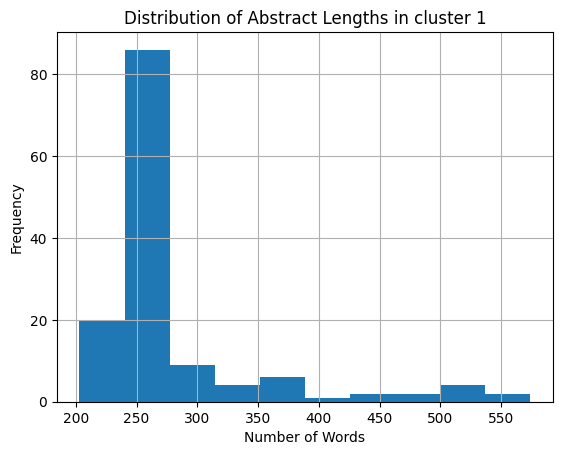

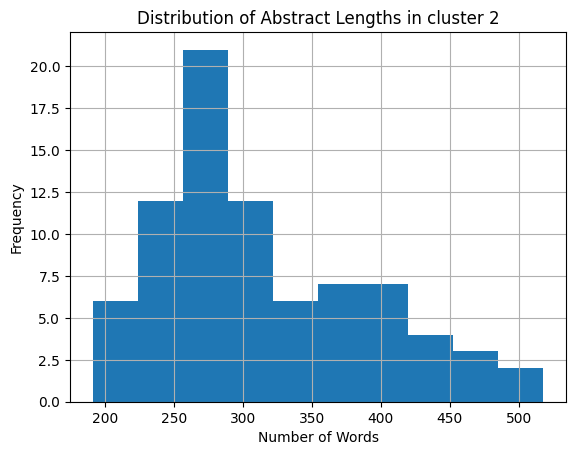

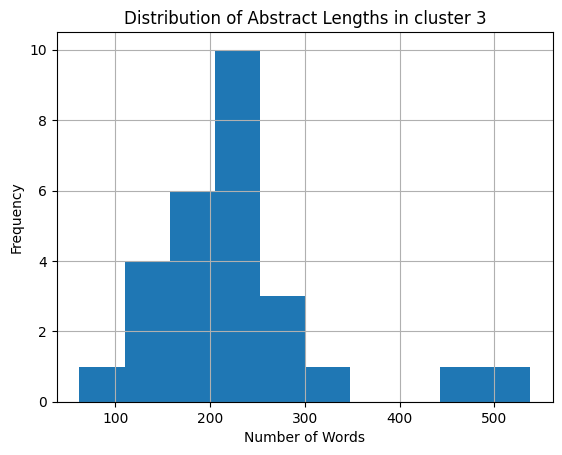

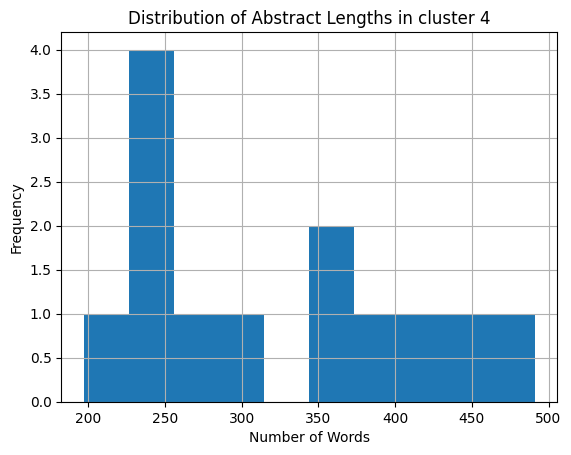

In [226]:
import matplotlib.pyplot as plt

for clt in range(4):
    plt.hist([len(abstract) for abstract in df_cluster.loc[df_cluster["cluster"] == clt, "abstracts_scibert"].apply(lambda x: str(x).split())])
    plt.xlabel("Number of Words")
    plt.ylabel("Frequency")
    plt.title(f"Distribution of Abstract Lengths in cluster {clt+1}")
    plt.grid(True)
    plt.show()

On observe que la longueur des abstracts varie fortement d’un cluster à l’autre. Les clusters 1 et 3 se caractérisent par une majorité d’abstracts relativement courts, avec une longueur généralement comprise entre 200 et 300 mots. Le cluster 2, quant à lui, présente une distribution plus étalée, avec une proportion notable d’abstracts dépassant les 400 mots. Enfin, le cluster 4 se distingue par des effectifs plus faibles, mais une répartition des longueurs globalement homogène.

### Frequences des mots dans le corpus de chaque cluster

2615


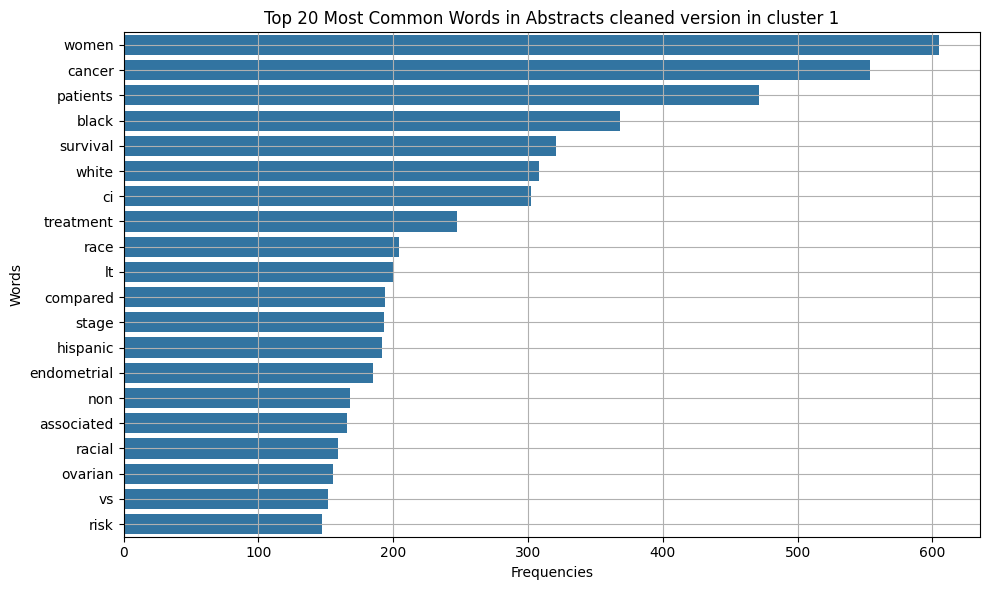

2002


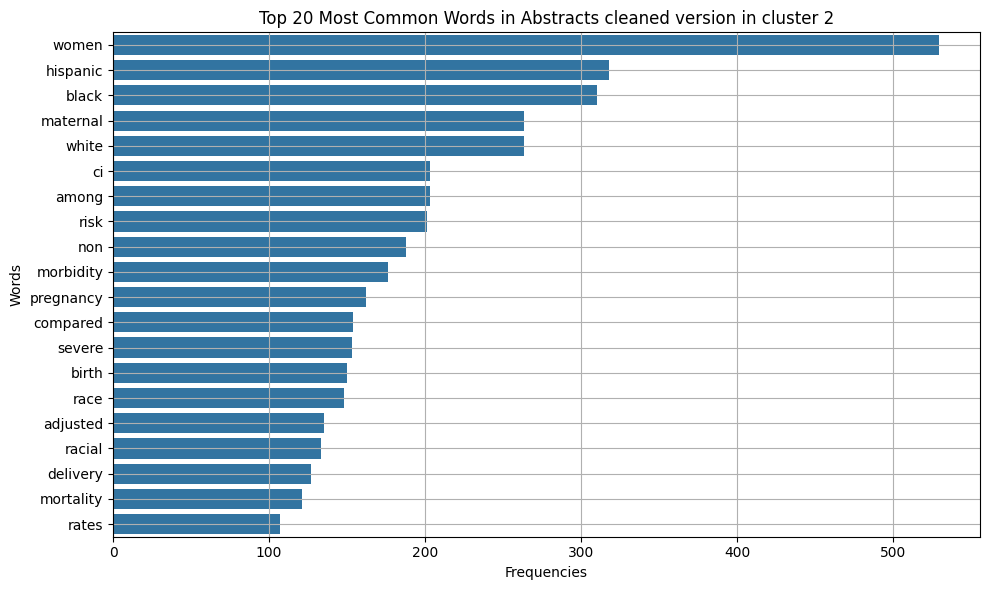

1349


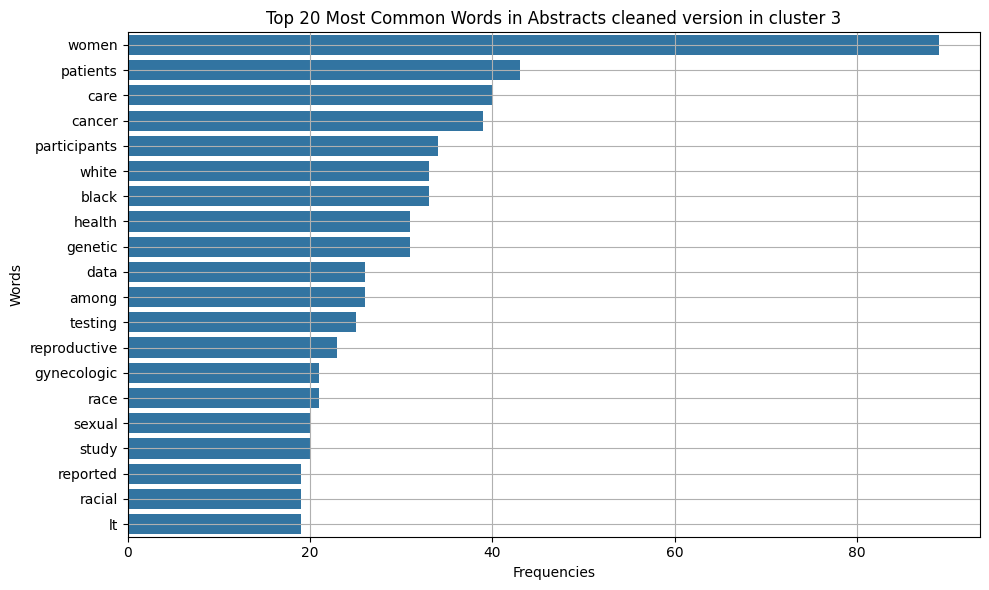

741


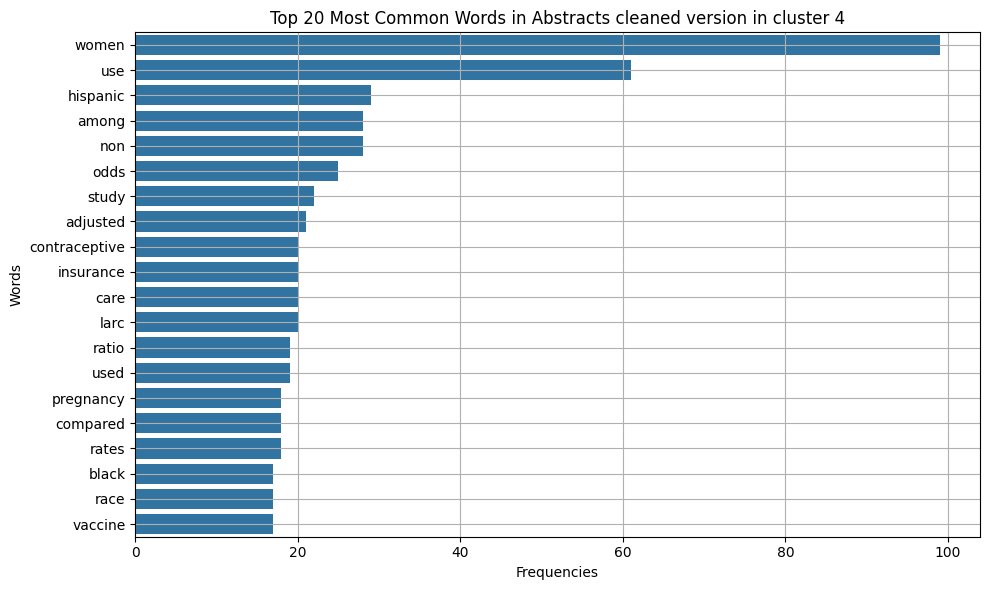

In [ ]:
from Modules.graphic_drawer import GraphicDrawer

for clt in range(4):
    all_absracts_cleaned = df_cluster.loc[df_cluster["cluster"] == clt, "processed_abstract"].dropna()
    all_absracts_cleaned = " ".join(all_absracts_cleaned)
    dict_of_words_occurences = text_processor.count_word_frequencies(text=all_absracts_cleaned, top_n=10000, preprocess=False)
    print(len(dict_of_words_occurences))

    graphic_drawer = GraphicDrawer()
    graphic_drawer.draw_bar_plot(dict_of_words_occurences, top_n=20, title=f"Top 20 Most Common Words in Abstracts cleaned version in cluster {1+clt}", ylabel="Words", xlabel="Frequencies")

# 4664

L’analyse des mots les plus fréquents met en évidence une structuration thématique claire des clusters. Le cluster 1 est principalement centré sur l’oncologie et les disparités raciales, tandis que le cluster 2 regroupe des études en santé maternelle, également marquées par des inégalités selon l’origine ethnique. Enfin, le cluster 3 apparaît plus transversal, regroupant des travaux portant sur les soins de santé, la génétique et la santé reproductive. Le cluster 4 quant à lui regroupe principalement des articles portant sur l’utilisation des méthodes contraceptives, en particulier les LARC, avec une analyse des disparités selon les caractéristiques démographiques et socio-économiques.

### Analyse du bruit - cluster -1

In [233]:
prop_study_type.loc[prop_study_type["cluster"] == -1]

,cluster,processed_study_type,nb_articles,Total,proportion
0,-1.0,Retrospective Cohort,27,53,51.0
1,-1.0,Cross Sectional,9,53,17.0
2,-1.0,Prospective Cohort,9,53,17.0
3,-1.0,Registry,4,53,8.0
4,-1.0,RCT,3,53,6.0
5,-1.0,Case Control,1,53,2.0


Le cluster -1, identifié comme du bruit, regroupe des articles de nature hétérogène, sans structure thématique claire. Bien qu’une majorité d’études de cohorte rétrospectives y soit observée, la diversité des types d’études suggère que ces articles ne présentent pas de similarités suffisantes pour être intégrés dans les autres clusters.

2217


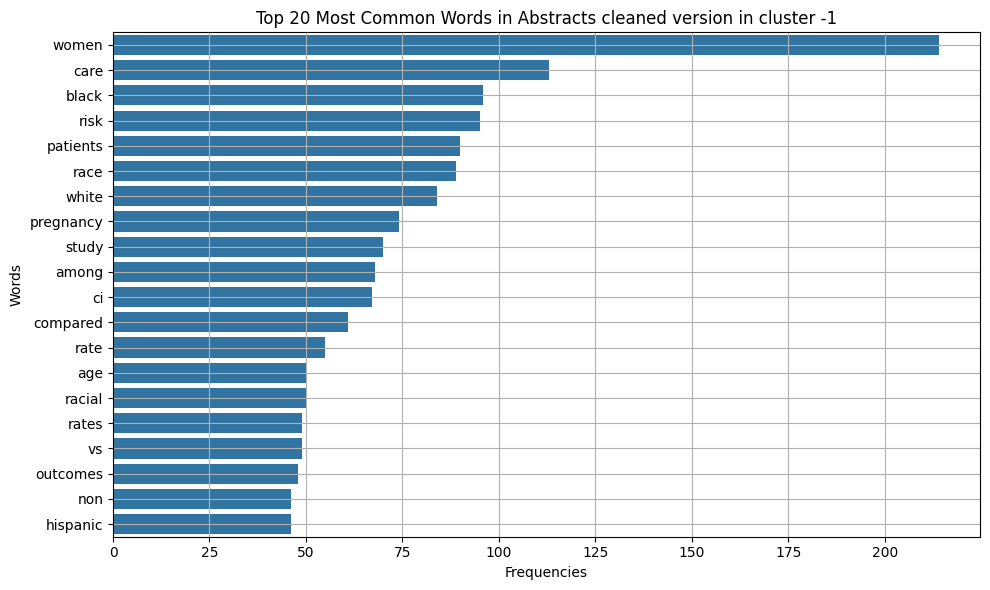

In [ ]:
all_absracts_cleaned = df_cluster.loc[df_cluster["cluster"] == -1, "processed_abstract"].dropna()
all_absracts_cleaned = " ".join(all_absracts_cleaned)
dict_of_words_occurences = text_processor.count_word_frequencies(text=all_absracts_cleaned, top_n=10000, preprocess=False)
print(len(dict_of_words_occurences))

graphic_drawer = GraphicDrawer()
graphic_drawer.draw_bar_plot(dict_of_words_occurences, top_n=20, title=f"Top 20 Most Common Words in Abstracts cleaned version in cluster {-1}", ylabel="Words", xlabel="Frequencies")
